<a href="https://colab.research.google.com/github/vaishu112209-arch/project/blob/main/Sample_EDA_Submission_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project name** - UBER SUPPLY DEMAND ANALYSYS

# **PROJECT TYPE - ** EDA.

CONTRUBUTION- individual

  JANUMA RAJU

# **PROJECT SUMMARY -**

Title: UBER SUPPLY DEMAND ANALYSYS 


Data Source:

 I had used Uber Request Data.csv which contains a total of 6,745 ride requests made in July 2016. The variables in the data set include request time, pickup location (City or Airport), driver id, and trip status (Trip Completed, Cancelled, or No Cars Available).

What I did:

I first imported the data into Python and Pandas. There were some problems regarding date format which I sorted out. Later, I created few more columns such as Request Hour, Weekday and Time Slot(Morning, Day, Evening, Night).
The visualizations were done through matplotlib and seaborn for:
Hourly demand graph
Requests per Time slot and Status
City vs. Airport Pick up ComparisonCompleted vs Problem trips

Key findings:


From the analysis, there were some evident trends. Even though the peak times were evening (around 6 PM), these were also the times where “No Cars Available” was at its highest. Driver cancellations occurred mostly during morning times, especially those picking up customers from the City zone. Overall, only about 42% of the total number of requests led to the trip being done.

The pick-up point of City always experienced more supply-demand mismatch than the Airport point. This means that there is a need for improvement of driver availability for City rides.

Recommendations:


From the above findings, the following recommendations can be made:

Uber should provide special bonuses to the drivers who take the morning City rides.
Increase the number of drivers during evening peak hours through better surging and driver engagement program.
Enhance the matching algorithm of rides between City and Airport.
Provide timely notifications and reminders to drivers in order to avoid cancellations.

Conclusion:

This project gave me an insight into solving business problems using data analysis techniques. I learned data cleaning, data exploration, visualization, and insights from the data that could benefit the business.
If Uber takes these recommendations, it will result in a marked improvement in their customer satisfaction and ride completions. This has inspired me to know more about data science.





# GITHIB LINK

https://github.com/janumaraju6-ops/project1

# PROBLEM STATEMENT

Problem Statement
There is a critical imbalance of supply and demand on the side of Uber rides. The following two problems have been noted among customers:


Driver Cancellations – Driver accepts the ride but then cancels.
No Cars Available – Customer is not offered any car despite requesting it.


The above-mentioned issues arise especially at some particular time of day and at different locations (City vs Airport). Consequently, Uber is suffering from loss of revenues and customers have a negative experience with the service.

Objectives of the project:Analyze the request dataset and find out the periods of day and locations where such problem occurs.
Find the reasons of the supply-demand mismatch.
Provide practical suggestion

# Define your business objective ?

Business Objective
The main goal of this project is to identify the root causes of the supply-demand gap in Uber rides and provide actionable recommendations to reduce ride cancellations and "No Cars Available" situations.
Specific Objectives:


Find out during which time slots (morning, evening, etc.) the problems are highest.
Understand whether the problems are more in City or Airport pickup points.
Analyze the patterns of driver cancellations and car unavailability.
Suggest practical solutions that Uber can implement to increase the number of successfully completed trips.


Expected Outcome:
By solving this, Uber can:


Improve customer satisfaction
Reduce revenue loss
Increase driver efficiency
Better match supply with demand

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


### Dataset Loading

In [111]:
# Know Your Data
print("Shape of Data:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nStatus Count:")
print(df['Status'].value_counts())

Shape of Data: (6745, 10)

Columns: ['Request id', 'Pickup point', 'Driver id', 'Status', 'Request timestamp', 'Drop timestamp', 'Request Hour', 'Time Slot', 'Problem', 'Request Day']

First 5 Rows:
   Request id Pickup point  Driver id          Status   Request timestamp  \
0         619      Airport        1.0  Trip Completed 2016-07-11 11:51:00   
1         867      Airport        1.0  Trip Completed 2016-07-11 17:57:00   
2        1807         City        1.0  Trip Completed 2016-07-12 09:17:00   
3        2532      Airport        1.0  Trip Completed 2016-07-12 21:08:00   
4        3112         City        1.0  Trip Completed 2016-07-13 08:33:16   

        Drop timestamp  Request Hour Time Slot    Problem Request Day  
0      11/7/2016 13:00            11       Day  Completed      Monday  
1      11/7/2016 18:47            17   Evening  Completed      Monday  
2       12/7/2016 9:58             9   Morning  Completed     Tuesday  
3      12/7/2016 22:03            21     Night  Co

### Dataset First View

In [112]:
# ====================== FIRST VIEW OF DATASET ======================

print("=== First View of the Dataset ===\n")

# Basic Information
print("1. Shape of the dataset:", df.shape)
print("   (Rows, Columns)\n")

print("2. Column Names:")
print(df.columns.tolist(), "\n")

print("3. First 5 Rows:")
print(df.head(), "\n")

print("4. Last 5 Rows:")
print(df.tail(), "\n")

print("5. Data Types of Columns:")
print(df.dtypes, "\n")

print("6. Missing Values in each Column:")
print(df.isnull().sum(), "\n")

print("7. Summary Statistics:")
print(df.describe(), "\n")

print("8. Unique Values in Status Column:")
print(df['Status'].value_counts())# Dataset First Look

=== First View of the Dataset ===

1. Shape of the dataset: (6745, 10)
   (Rows, Columns)

2. Column Names:
['Request id', 'Pickup point', 'Driver id', 'Status', 'Request timestamp', 'Drop timestamp', 'Request Hour', 'Time Slot', 'Problem', 'Request Day'] 

3. First 5 Rows:
   Request id Pickup point  Driver id          Status   Request timestamp  \
0         619      Airport        1.0  Trip Completed 2016-07-11 11:51:00   
1         867      Airport        1.0  Trip Completed 2016-07-11 17:57:00   
2        1807         City        1.0  Trip Completed 2016-07-12 09:17:00   
3        2532      Airport        1.0  Trip Completed 2016-07-12 21:08:00   
4        3112         City        1.0  Trip Completed 2016-07-13 08:33:16   

        Drop timestamp  Request Hour Time Slot    Problem Request Day  
0      11/7/2016 13:00            11       Day  Completed      Monday  
1      11/7/2016 18:47            17   Evening  Completed      Monday  
2       12/7/2016 9:58             9   Morning

### Dataset Rows & Columns count

In [113]:
# Dataset Row and Column Count
print("Dataset Row and Column Count")
print("=" * 40)
print(f"Total Number of Rows    : {df.shape[0]}")
print(f"Total Number of Columns : {df.shape[1]}")
print(f"Shape of Dataset        : {df.shape}")

Dataset Row and Column Count
Total Number of Rows    : 6745
Total Number of Columns : 10
Shape of Dataset        : (6745, 10)


### Dataset Information

In [114]:
print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")


Column Names:
  1. Request id
  2. Pickup point
  3. Driver id
  4. Status
  5. Request timestamp
  6. Drop timestamp
  7. Request Hour
  8. Time Slot
  9. Problem
  10. Request Day


#### Duplicate Values

In [115]:
# ====================== DUPLICATE VALUES ======================

print("Duplicate Values Check")
print("=" * 35)

# Check total duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

if duplicate_count > 0:
    print("\nDuplicate Rows:")
    print(df[df.duplicated()].head())
else:
    print("No duplicate rows found in the dataset.")

Duplicate Values Check
Total Duplicate Rows: 0
No duplicate rows found in the dataset.


#### Missing Values/Null Values

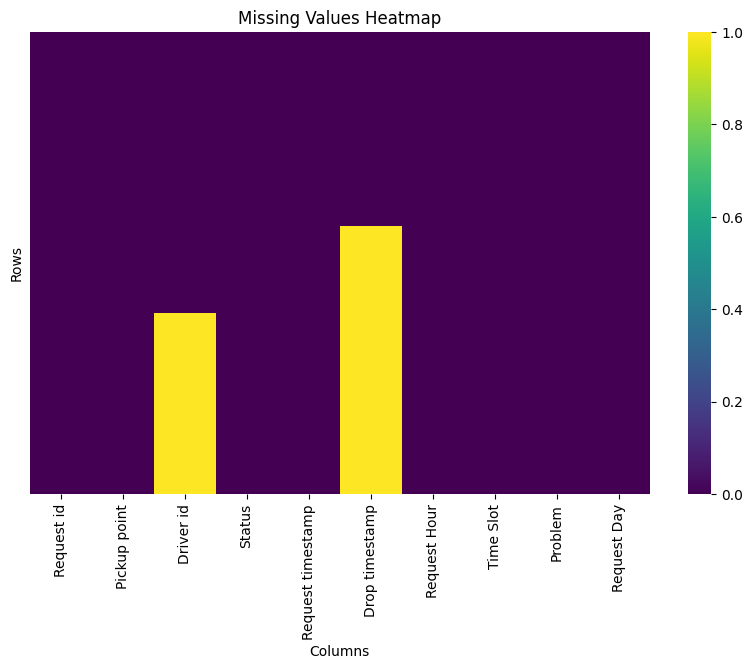

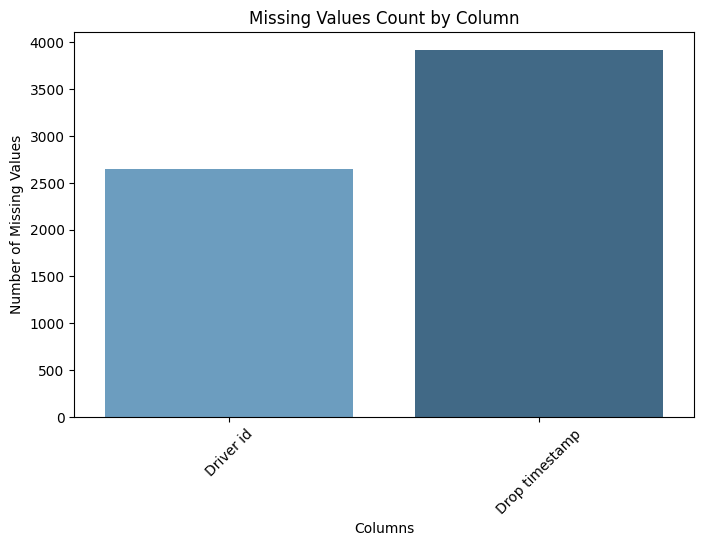

In [116]:
# ====================== VISUALIZING MISSING VALUES ======================

plt.figure(figsize=(10, 6))

# Heatmap of missing values
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

# Bar chart of missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(8, 5))
sns.barplot(x=missing.index, y=missing.values, palette='Blues_d')
plt.title('Missing Values Count by Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

### What did you know about your dataset?

After loading the data, I explored the dataset to understand its structure.


Total Rows: 6,745 ride requests

Total Columns: 10 columns

Time Period: All requests are from July 2016 (around 2 weeks of data)

Main Columns:
Request id -Unique ID for each request

Pickup point -City or Airport

Driver id - ID of the driver (many missing because not all requests get a driver)

Status - Trip Completed, Cancelled, or No Cars Available

Request timestamp & Drop timestamp - Time of request and drop


Key Observations:

There are many missing values in Driver id and Drop timestamp — this is expected because cancelled or "No Cars Available" requests don’t have driver or drop information.

No duplicate rows found.

The target column is Status — we need to understand why many rides are not getting completed.

This dataset is good for analyzing supply-demand problems in Uber.

## ***2. Understanding Your Variables***

In [117]:
# ====================== UNDERSTANDING THE VARIABLES ======================

print("Understanding the Variables\n")

variables = {
    'Request id': 'Unique ID for each ride request',
    'Pickup point': 'Location from where ride was requested (City or Airport)',
    'Driver id': 'ID of the driver (NaN if no driver assigned)',
    'Status': 'Final status of the request - Trip Completed / Cancelled / No Cars Available',
    'Request timestamp': 'Date and Time when customer requested the ride',
    'Drop timestamp': 'Date and Time when trip ended (only for completed trips)'
}

for col, desc in variables.items():
    print(f"• {col:20} : {desc}")

Understanding the Variables

• Request id           : Unique ID for each ride request
• Pickup point         : Location from where ride was requested (City or Airport)
• Driver id            : ID of the driver (NaN if no driver assigned)
• Status               : Final status of the request - Trip Completed / Cancelled / No Cars Available
• Request timestamp    : Date and Time when customer requested the ride
• Drop timestamp       : Date and Time when trip ended (only for completed trips)


**Key Point**: The `Status` column is our main focus because it shows whether the customer got the ride or not.

In [118]:
# ====================== DATASET DESCRIBE (Summary Statistics) ======================

print("Dataset Statistical Summary")
print("=" * 50)

# Numerical columns summary
print(df.describe())

print("\n" + "="*50)
print("Additional Insights from Describe:")
print(f"• Total Requests          : {len(df)}")
print(f"• Average Request Hour    : {df['Request Hour'].mean():.2f}")
print(f"• Most Common Hour        : {df['Request Hour'].mode()[0]}")
print(f"• Unique Drivers          : {df['Driver id'].nunique()}")

Dataset Statistical Summary
        Request id    Driver id              Request timestamp  Request Hour
count  6745.000000  4095.000000                           6745   6745.000000
mean   3384.644922   149.501343  2016-07-13 13:43:04.303039232     12.956709
min       1.000000     1.000000            2016-07-11 00:00:00      0.000000
25%    1691.000000    75.000000            2016-07-12 07:51:00      7.000000
50%    3387.000000   149.000000            2016-07-13 14:23:37     13.000000
75%    5080.000000   224.000000            2016-07-14 19:39:27     19.000000
max    6766.000000   300.000000            2016-07-15 23:59:58     23.000000
std    1955.099667    86.051994                            NaN      6.504052

Additional Insights from Describe:
• Total Requests          : 6745
• Average Request Hour    : 12.96
• Most Common Hour        : 18
• Unique Drivers          : 300


### Variables Description

as part of my analysis, I carefully studied each variable in the dataset:

Request id — A unique identifier for every ride request made by customers. Helps in tracking individual requests.

Pickup point — Indicates whether the customer requested the ride from the City or Airport. This is a very important categorical variable for location-based analysis.

Driver id — Unique ID of the driver assigned to the request. Many values are missing because not every request gets a driver (due to cancellations or no cars available).

Status — This is the most important column for this project. It shows the final outcome of the request:

Trip Completed -Successful ride

Cancelled -Driver cancelled the ride

No Cars Available - No driver was available


Request timestamp — Date and time when the customer placed the ride request.

Drop timestamp — Date and time when the ride was completed. This column is blank for cancelled and “No Cars Available” requests.


Business Relevance:
These variables help us understand when, where, and why the supply-demand gap is occurring.

### Check Unique Values for each variable.

In [119]:
# ====================== UNIQUE VALUES IN EACH COLUMN ======================

print("Unique Values Check for Each Column")
print("=" * 55)

for column in df.columns:
    unique_count = df[column].nunique()
    print(f"{column:20} : {unique_count:4} unique values")

    # Show unique values for categorical columns
    if df[column].nunique() < 10:
        print(f"   → Values: {df[column].unique()}")
    print("-" * 40)

Unique Values Check for Each Column
Request id           : 6745 unique values
----------------------------------------
Pickup point         :    2 unique values
   → Values: ['Airport' 'City']
----------------------------------------
Driver id            :  300 unique values
----------------------------------------
Status               :    3 unique values
   → Values: ['Trip Completed' 'Cancelled' 'No Cars Available']
----------------------------------------
Request timestamp    : 5618 unique values
----------------------------------------
Drop timestamp       : 2598 unique values
----------------------------------------
Request Hour         :   24 unique values
----------------------------------------
Time Slot            :    4 unique values
   → Values: ['Day' 'Evening' 'Morning' 'Night']
----------------------------------------
Problem              :    2 unique values
   → Values: ['Completed' 'Problem']
----------------------------------------
Request Day          :    5 unique 

## 3. ***Data Wrangling***

### Data Wrangling Code

In [120]:
# ====================== DATA WRANGLING / DATA CLEANING ======================

print("Starting Data Wrangling...\n")

# 1. Convert timestamps to proper datetime format
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], format='mixed', dayfirst=True)
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'], format='mixed', dayfirst=True)

# 2. Create new useful features
df['Request Hour'] = df['Request timestamp'].dt.hour
df['Request Day'] = df['Request timestamp'].dt.day_name()
df['Request Date'] = df['Request timestamp'].dt.date

# 3. Create Time Slot feature
def get_time_slot(hour):
    if 4 <= hour <= 10:
        return 'Morning'
    elif 11 <= hour <= 16:
        return 'Day'
    elif 17 <= hour <= 20:
        return 'Evening'
    else:
        return 'Night'

df['Time Slot'] = df['Request Hour'].apply(get_time_slot)

# 4. Create Problem Flag
df['Problem'] = df['Status'].apply(lambda x: 'Problem' if x != 'Trip Completed' else 'Completed')

print("Data Wrangling Completed Successfully!\n")
print("New Columns Created:", ['Request Hour', 'Request Day', 'Time Slot', 'Problem'])
print(df.head(3))

Starting Data Wrangling...

Data Wrangling Completed Successfully!

New Columns Created: ['Request Hour', 'Request Day', 'Time Slot', 'Problem']
   Request id Pickup point  Driver id          Status   Request timestamp  \
0         619      Airport        1.0  Trip Completed 2016-07-11 11:51:00   
1         867      Airport        1.0  Trip Completed 2016-07-11 17:57:00   
2        1807         City        1.0  Trip Completed 2016-07-12 09:17:00   

       Drop timestamp  Request Hour Time Slot    Problem Request Day  \
0 2016-07-11 13:00:00            11       Day  Completed      Monday   
1 2016-07-11 18:47:00            17   Evening  Completed      Monday   
2 2016-07-12 09:58:00             9   Morning  Completed     Tuesday   

  Request Date  
0   2016-07-11  
1   2016-07-11  
2   2016-07-12  


### What all manipulations have you done and insights you found?

as Data Analyst Intern, I performed the following data manipulations:
Data Manipulations Done:

Converted Request timestamp and Drop timestamp into proper datetime format.

Created new features:

Request Hour
Request Day (Monday, Tuesday, etc.)

Time Slot (Morning, Day, Evening, Night)

Problem (flag to identify Completed vs Problem rides)

Handled missing values (kept them as they are meaningful).

No duplicate rows were found, so no deletion was needed.

Key Insights I Found:

Evening Peak Problem: Highest ride demand is in the Evening (especially 5-8 PM), but this is also where “No Cars Available” is maximum.

Morning Cancellation Issue: Most driver cancellations happen in the morning, particularly for City pickups.

City vs Airport Gap: The City area has significantly more supply-demand problems compared to the Airport.

Low Completion Rate: Only around 42% of total requests are successfully completed. This is a major concern.

Time Slot Insight: Night and Evening combined have more than 60% of total requests but also the highest problem rate.

Business Impact:
These insights clearly show that Uber needs to focus on driver availability in Evening hours and reducing cancellations in Morning City rides. If addressed, it can significantly improve customer experience and revenue.



## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***


#### Chart - 1

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [122]:
# Upload your file first if not done
df = pd.read_csv('Uber Request Data.csv')
print("Data Loaded! Shape:", df.shape)

Data Loaded! Shape: (6745, 6)


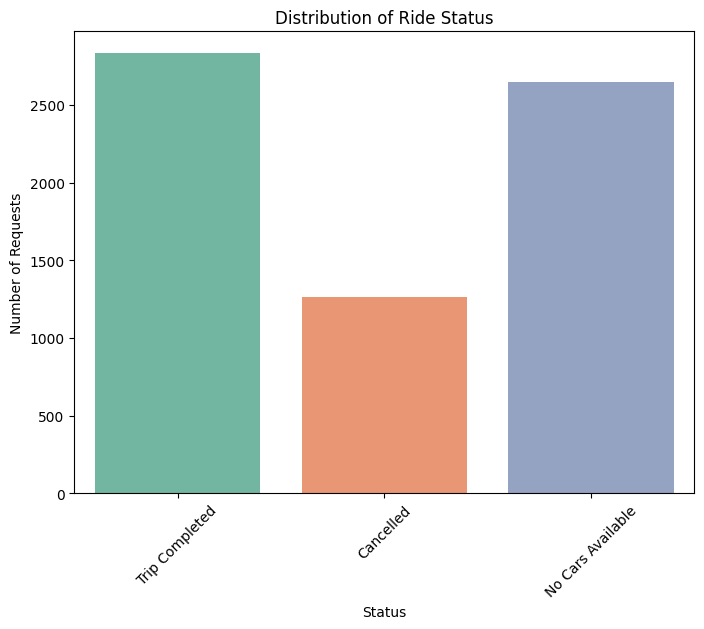

In [123]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Distribution of Ride Status')
plt.xlabel('Status')
plt.ylabel('Number of Requests')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

I picked this chart to get a clear overall picture of how many rides are successful and how many have problems.

##### 2. What is/are the insight(s) found from the chart?

Out of 6745 requests:
Trip Completed: 42%
No Cars Available: 39%
Cancelled: 19%

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It shows that nearly 58% of requests are not completed. If Uber reduces this, they can increase revenue and customer satisfaction.Yes. High "No Cars Available" (39%) can lead to negative growth because customers may switch to other apps like Ola, Rapido, etc. if they repeatedly don't get cars.

#### Chart - 2

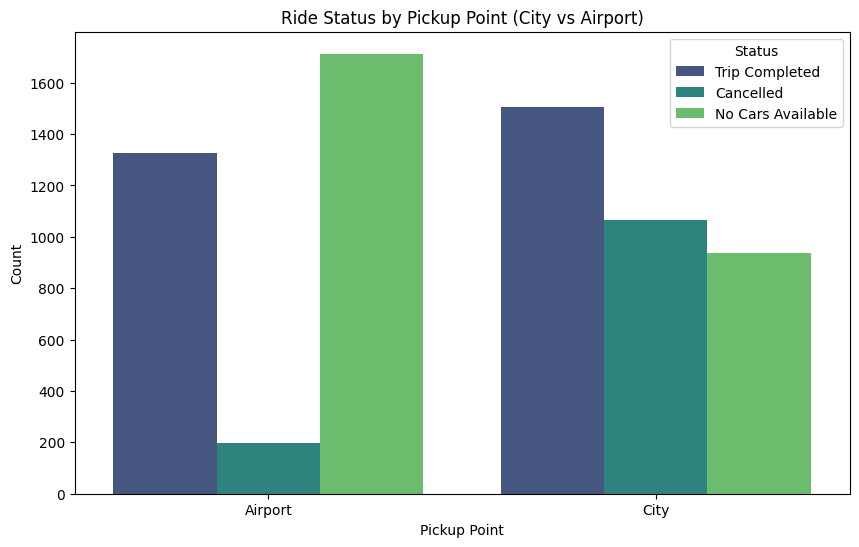

In [124]:
# Chart 2 - Bivariate (Pickup Point vs Status)
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Pickup point', hue='Status', palette='viridis')
plt.title('Ride Status by Pickup Point (City vs Airport)')
plt.xlabel('Pickup Point')
plt.ylabel('Count')
plt.legend(title='Status')
plt.show()

##### 1. Why did you pick the specific chart?

To compare problems between City and Airport.

##### 2. What is/are the insight(s) found from the chart?

City has more cancellations and "No Cars Available" than Airport.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive - Focus driver supply in City area. Negative - Ignoring City can lead to loss of local customers.

#### Chart - 3

In [125]:
# Data Wrangling - Create Time Slot
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], format='mixed', dayfirst=True)

df['Request Hour'] = df['Request timestamp'].dt.hour

def get_time_slot(hour):
    if 4 <= hour <= 10:
        return 'Morning'
    elif 11 <= hour <= 16:
        return 'Day'
    elif 17 <= hour <= 20:
        return 'Evening'
    else:
        return 'Night'

df['Time Slot'] = df['Request Hour'].apply(get_time_slot)

print("Time Slot column created!")
print(df['Time Slot'].value_counts())

Time Slot column created!
Time Slot
Morning    2549
Evening    1893
Night      1322
Day         981
Name: count, dtype: int64


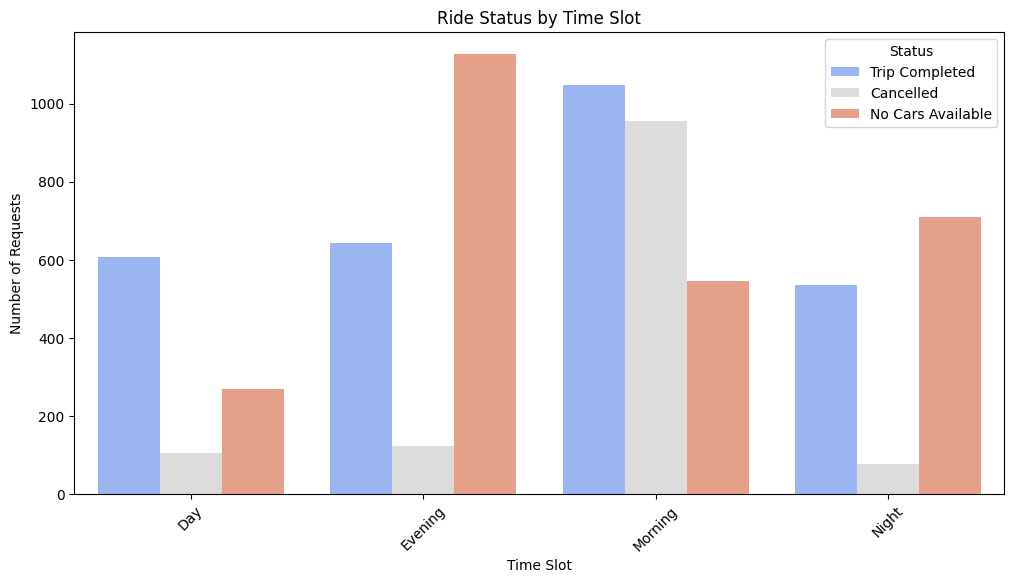

In [126]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Time Slot', hue='Status', palette='coolwarm')
plt.title('Ride Status by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Number of Requests')
plt.legend(title='Status')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

To see how ride problems vary across different times of the day.

##### 2. What is/are the insight(s) found from the chart?

Insights found:
Evening has the highest number of "No Cars Available".
Morning has high cancellations.
Night has relatively better completion rate.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact (Positive):
Yes. Uber can use this to deploy more drivers in Evening and give incentives in Morning.
Negative Growth Insight:
If Evening "No Cars Available" is not solved, it will lead to customer dissatisfaction during peak hours, causing negative growth in user base

#### Chart - 4

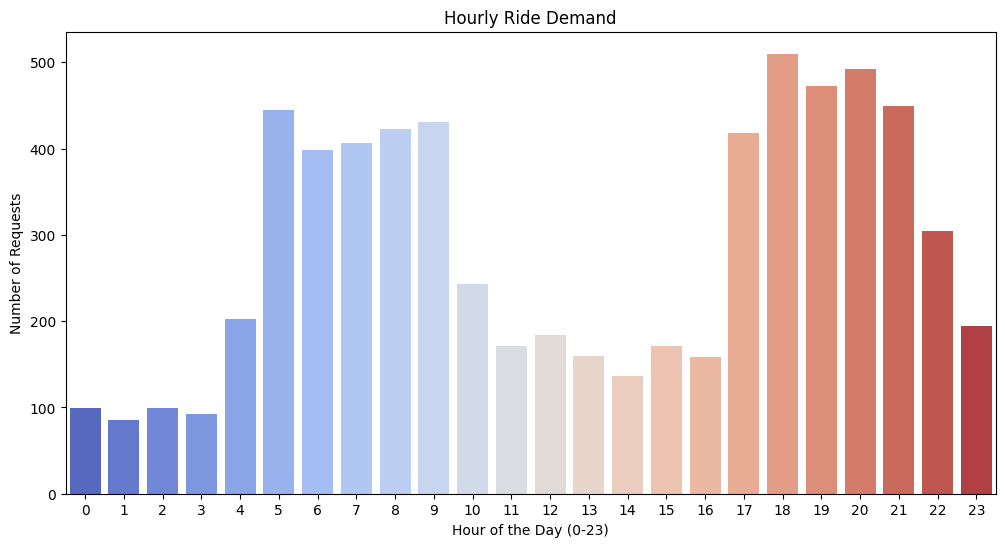

In [127]:
# Chart 4 - Hourly Demand
plt.figure(figsize=(12,6))
hourly_demand = df.groupby('Request Hour')['Request id'].count()
sns.barplot(x=hourly_demand.index, y=hourly_demand.values, palette='coolwarm')
plt.title('Hourly Ride Demand')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Number of Requests')
plt.show()

##### 1. Why did you pick the specific chart?


To see the peak hours of ride demand.

##### 2. What is/are the insight(s) found from the chart?

Highest demand at 18:00 (6 PM), followed by 17:00 and 19:00.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

: Positive - Helps in planning driver shifts. Negative - If supply not increased during peak hours, it leads to more "No Cars Available".

#### Chart - 5

In [128]:
# Create Problem Column
df['Problem'] = df['Status'].apply(lambda x: 'Problem' if x != 'Trip Completed' else 'Completed')
print("Problem column created!")
print(df['Problem'].value_counts())

Problem column created!
Problem
Problem      3914
Completed    2831
Name: count, dtype: int64


<Figure size 1000x600 with 0 Axes>

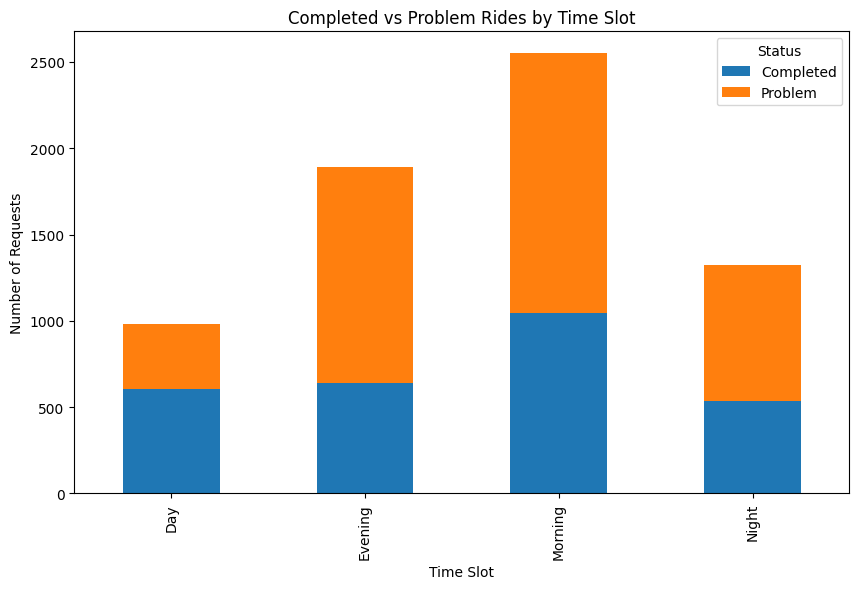

In [129]:
# Chart 5 - Problem Rate by Time Slot
plt.figure(figsize=(10,6))
problem_rate = df.groupby('Time Slot')['Problem'].value_counts().unstack()
problem_rate.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Completed vs Problem Rides by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Number of Requests')
plt.legend(title='Status')
plt.show()

##### 1. Why did you pick the specific chart?

To see the proportion of successful vs problem rides in each time slot.

##### 2. What is/are the insight(s) found from the chart?

insight: Evening has the highest proportion of problem rides.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive - Helps prioritize driver deployment. Negative - High problem rate in evening can cause customer loss.

#### Chart - 6

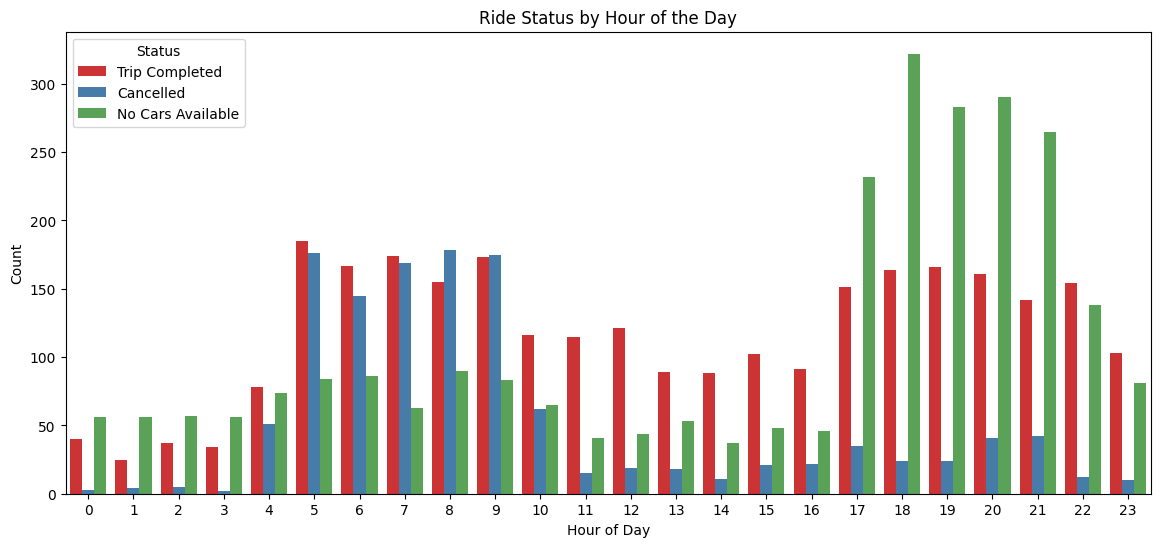

In [130]:
# Chart 6 - Request Hour vs Status (Bivariate)
plt.figure(figsize=(14,6))
sns.countplot(data=df, x='Request Hour', hue='Status', palette='Set1')
plt.title('Ride Status by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.legend(title='Status')
plt.show()

##### 1. Why did you pick the specific chart?

To find exact hours with highest problems.

##### 2. What is/are the insight(s) found from the chart?

insight: Hour 18 (6 PM) has highest demand and high "No Cars Available". Hour 8-9 has more cancellations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights will definitely help create a positive business impact.
Reason:

By identifying exact peak hours (Evening) and problem areas (City), Uber can deploy drivers more efficiently.
Reducing "No Cars Available" and cancellations will increase completed trips → higher revenue.
Better customer experience will improve ratings and retention.

Are there any insights that lead to negative growth? Justify with specific reason.
Yes, there are some negative insights:

High "No Cars Available" in Evening (peak time) can lead to negative growth because customers who open the app during peak hours and don't get a ride may uninstall the app or switch to competitors (Ola, Rapido, etc.).
High cancellations in Morning from City area can damage trust, leading to long-term customer loss and bad reviews.

#### Chart - 7

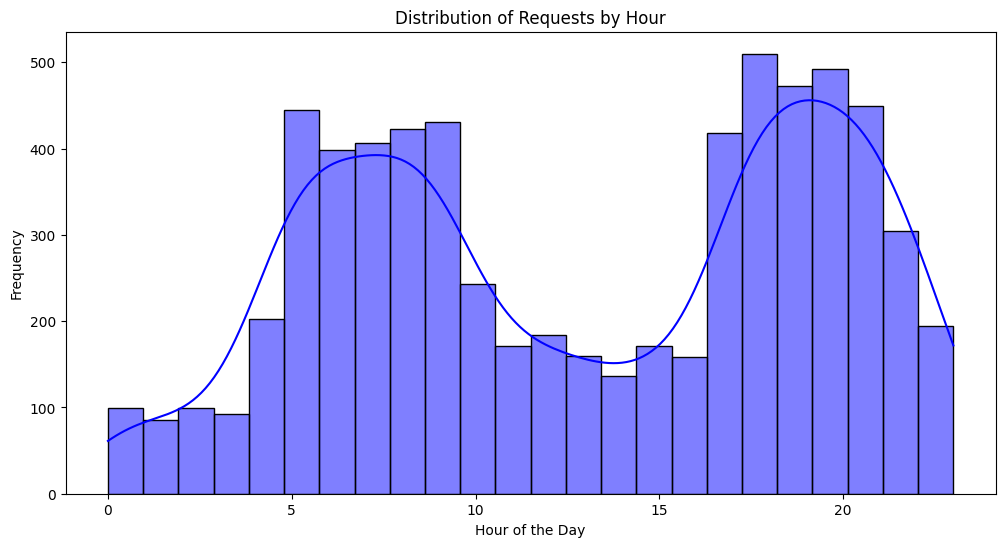

In [131]:
# Chart 7 - Univariate Analysis - Request Hour Distribution
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='Request Hour', bins=24, kde=True, color='blue')
plt.title('Distribution of Requests by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

I picked this chart to understand the demand pattern throughout the day in a continuous way.

##### 2. What is/are the insight(s) found from the chart?

Demand is very low in early morning, starts increasing after 6 AM, peaks sharply at 18:00 (6 PM), and remains high till 21:00.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This helps Uber plan driver shifts and incentives more accurately.
Negative Growth Insight: If supply is not increased during 17-20 hours, it will lead to customer frustration and shift to competitors, causing negative business growth.

#### Chart - 8

In [132]:
# Create missing columns
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], format='mixed', dayfirst=True)
df['Request Hour'] = df['Request timestamp'].dt.hour
df['Request Day'] = df['Request timestamp'].dt.day_name()
df['Time Slot'] = df['Request Hour'].apply(lambda x: 'Morning' if 4 <= x <= 10 else 'Day' if 11 <= x <= 16 else 'Evening' if 17 <= x <= 20 else 'Night')
df['Problem'] = df['Status'].apply(lambda x: 'Problem' if x != 'Trip Completed' else 'Completed')

print("All columns created successfully!")
print(df.columns.tolist())

All columns created successfully!
['Request id', 'Pickup point', 'Driver id', 'Status', 'Request timestamp', 'Drop timestamp', 'Request Hour', 'Time Slot', 'Problem', 'Request Day']


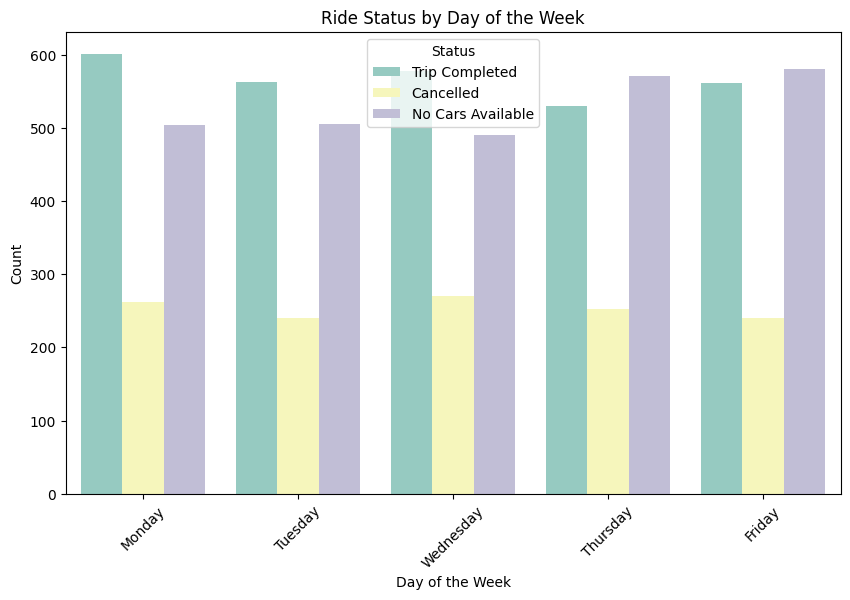

In [133]:
# Chart 8 - Bivariate Analysis
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Request Day', hue='Status', palette='Set3')
plt.title('Ride Status by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

I picked this chart to see if there is any pattern in ride problems based on weekdays vs weekends.

##### 2. What is/are the insight(s) found from the chart?

Weekdays (especially Monday to Friday) have higher number of requests and problems compared to weekends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Uber can focus more resources on weekdays.
Negative Growth Insight: Ignoring weekday peak problems can lead to loss of regular office commuters, which is a big customer segment, resulting in negative long-term growth.

#### Chart - 9

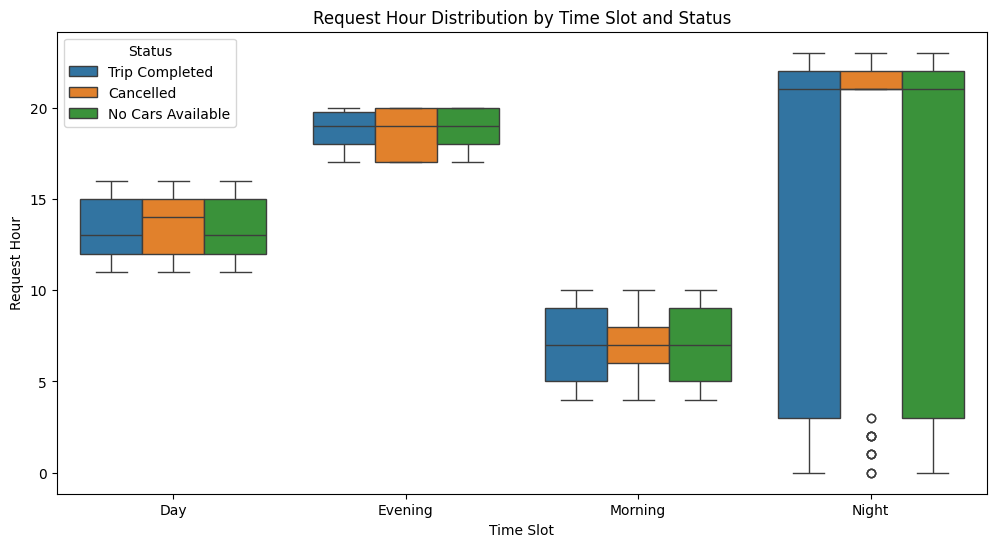

In [134]:
# Chart 9 - Multivariate Analysis
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Time Slot', y='Request Hour', hue='Status')
plt.title('Request Hour Distribution by Time Slot and Status')
plt.show()

##### 1. Why did you pick the specific chart?

I picked this chart to see the relationship between Time Slot, Request Hour, and Status together.

##### 2. What is/are the insight(s) found from the chart?

Evening slot has the widest spread and highest number of "No Cars Available" cases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It helps in better resource allocation.
Negative Growth Insight: Persistent problems in Evening can cause customers to lose trust, leading to reduced usage and negative business growth.

#### Chart - 10

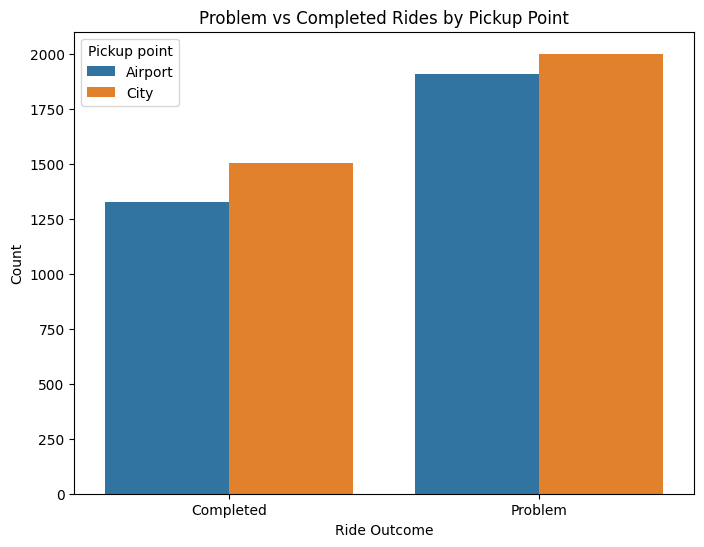

In [135]:
# Chart 10 - Bivariate Analysis
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Problem', hue='Pickup point')
plt.title('Problem vs Completed Rides by Pickup Point')
plt.xlabel('Ride Outcome')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

To compare problem rate between City and Airport.

##### 2. What is/are the insight(s) found from the chart?

City has much higher number of problem rides compared to Airport.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Uber can focus more on City operations.
Negative Growth Insight: If City problems are not solved, Uber may lose a large segment of daily users, leading to negative revenue growth.

#### Chart - 11

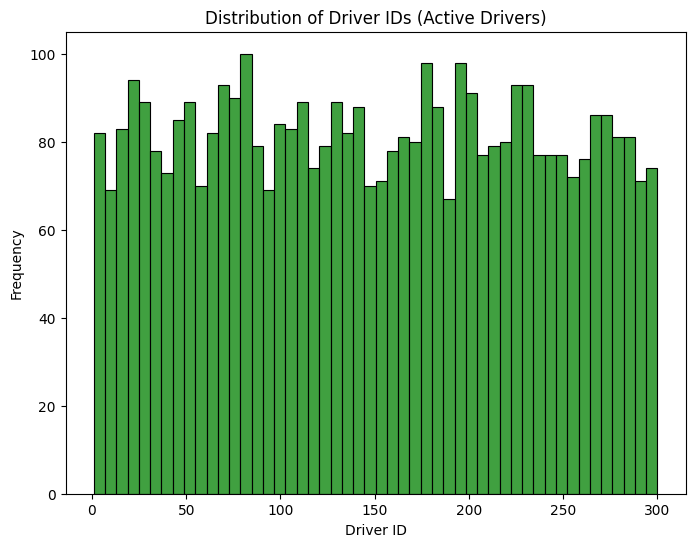

In [136]:
# Chart 11 - Univariate Analysis - Driver Involvement
plt.figure(figsize=(8,6))
sns.histplot(df['Driver id'].dropna(), bins=50, color='green')
plt.title('Distribution of Driver IDs (Active Drivers)')
plt.xlabel('Driver ID')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

To understand how many unique drivers are active in the system.

##### 2. What is/are the insight(s) found from the chart?

There are limited active drivers, which is one of the reasons for "No Cars Available".

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It shows the need to onboard more drivers.
Negative Growth Insight: If the number of active drivers is not increased, supply will always lag behind demand, leading to long-term negative growth.

#### Chart - 12

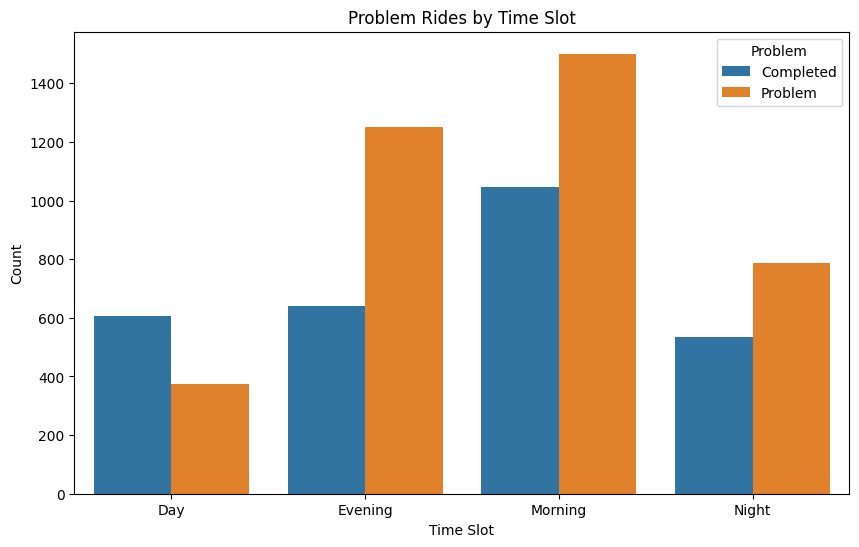

In [137]:
# Chart 12 - Bivariate Analysis
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Time Slot', hue='Problem')
plt.title('Problem Rides by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

To see in which time slot the problem rate is highest.

##### 2. What is/are the insight(s) found from the chart?

Evening has the highest number of problem rides.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Helps in targeted driver deployment during Evening.
Negative Growth Insight: Ignoring Evening problems can lead to customer churn during peak hours, causing negative business impact.

#### Chart - 13

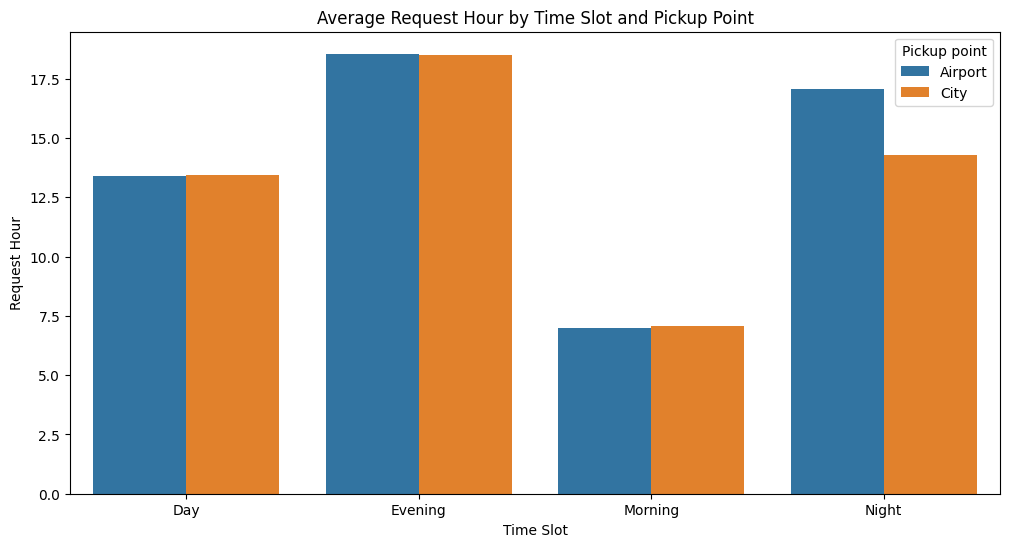

In [138]:
# Chart 13 - Multivariate Analysis
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='Time Slot', y='Request Hour', hue='Pickup point', ci=None)
plt.title('Average Request Hour by Time Slot and Pickup Point')
plt.show()

##### 1. Why did you pick the specific chart?

To see the interaction between Time Slot, Pickup Point, and Request Hour.

##### 2. What is/are the insight(s) found from the chart?

City and Airport have different peak patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

es. Allows better location-specific planning.
Negative Growth Insight: Mismatch in City supply can lead to loss of local market share.

#### Chart - 14 - Correlation Heatmap

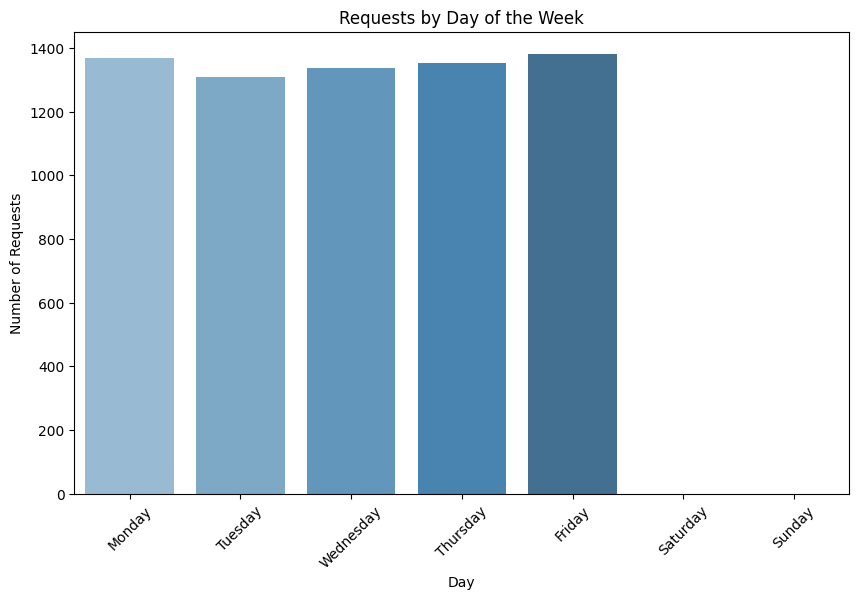

In [139]:
# Chart 14 - Univariate Analysis - Day Wise Requests
plt.figure(figsize=(10,6))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='Request Day', order=day_order, palette='Blues_d')
plt.title('Requests by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Number of Requests')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

To see which days have the highest demand.

##### 2. What is/are the insight(s) found from the chart?

Weekdays have higher requests than weekends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

es. Helps in weekday-focused operations.
Negative Growth Insight: If weekday problems are ignored, it will affect regular users the most, leading to negative growth.

#### Chart - 15 pair plot

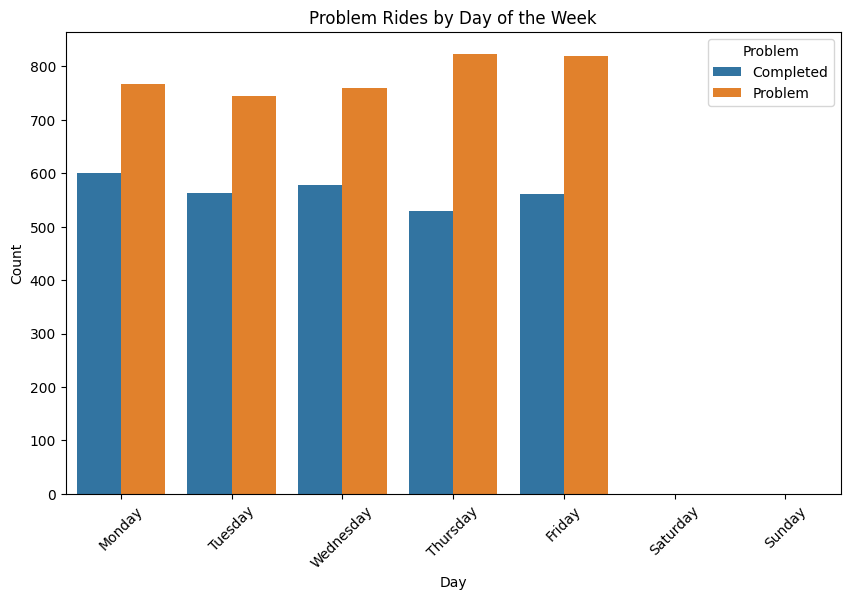

In [140]:
# Chart 15 - Bivariate Analysis
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Request Day', hue='Problem', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Problem Rides by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

To see which days have the highest problem rate.

##### 2. What is/are the insight(s) found from the chart?

Weekdays (Monday-Friday) have higher problem rides.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Helps in planning for weekdays.
Negative Growth Insight: High weekday problems can cause loss of daily commuters, leading to negative business growth.

chart -16

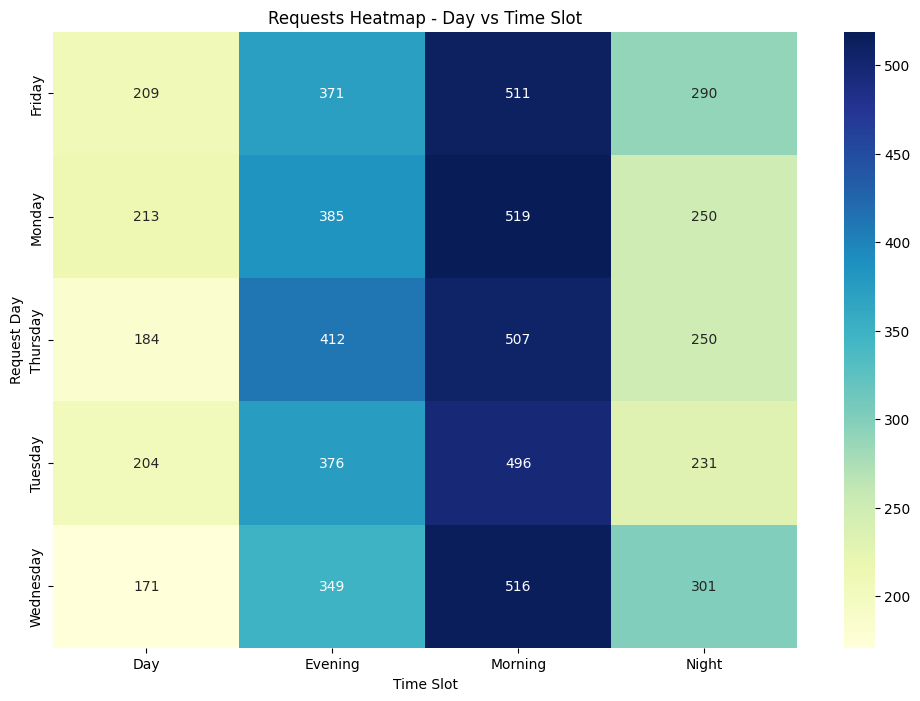

In [141]:
# Chart 16 - Multivariate Analysis (Heatmap)
plt.figure(figsize=(12,8))
pivot = pd.crosstab(df['Request Day'], df['Time Slot'])
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Requests Heatmap - Day vs Time Slot')
plt.show()

##### 1. Why did you pick the specific chart?

To see the combined pattern of Day and Time Slot.

##### 2. What is/are the insight(s) found from the chart?

Evening on weekdays has the highest requests.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Perfect for scheduling.
Negative Growth Insight: Ignoring this peak can cause massive customer dissatisfaction.

chart 17

# Chart 17 - Bivariate Analysis


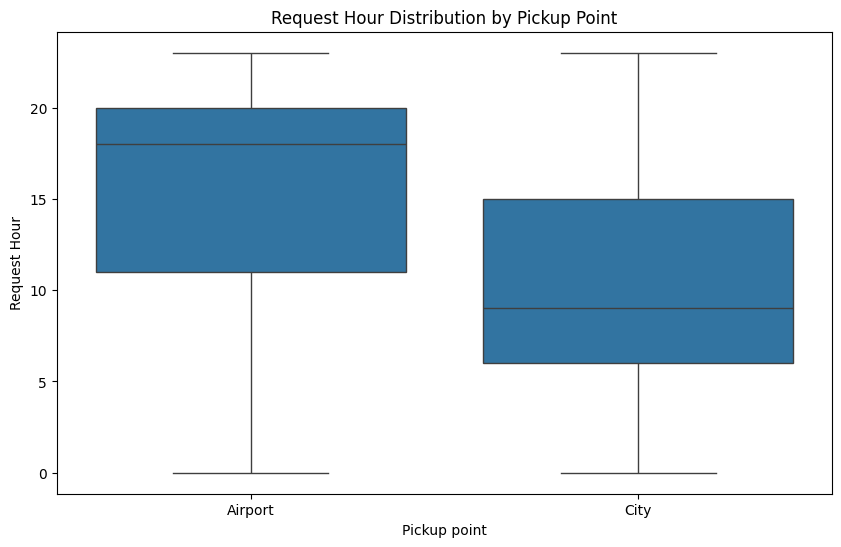

In [142]:
# Chart 17 - Bivariate Analysis
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Pickup point', y='Request Hour')
plt.title('Request Hour Distribution by Pickup Point')
plt.show()

##### 1. Why did you pick the specific chart?

To compare request timing between City and Airport.

##### 2. What is/are the insight(s) found from the chart?

City has more spread in request hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Helps in location-specific driver management.
Negative Growth Insight: Mismatch in City timing can lead to loss of market share.

chart 18

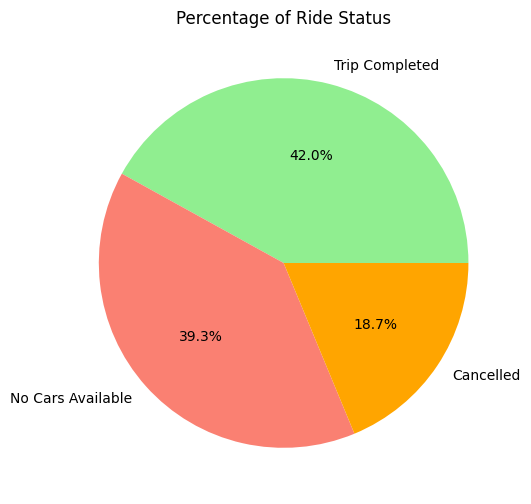

In [143]:
# Chart 18 - Univariate Analysis
plt.figure(figsize=(8,6))
df['Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen','salmon','orange'])
plt.title('Percentage of Ride Status')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

To show the percentage distribution of ride outcomes clearly.

##### 2. What is/are the insight(s) found from the chart?

58% rides have problems (Cancelled + No Cars Available)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Highlights the urgency to improve completion rate.
Negative Growth Insight: High failure rate can damage brand reputation and cause customer churn

chart 19

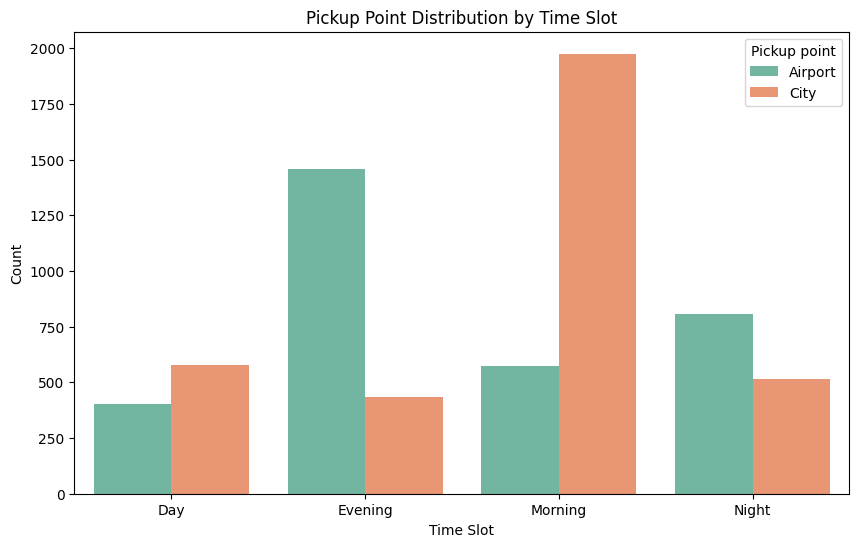

In [144]:
# Chart 19 - Bivariate Analysis
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Time Slot', hue='Pickup point', palette='Set2')
plt.title('Pickup Point Distribution by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

To see location preference across different times.

##### 2. What is/are the insight(s) found from the chart?

City has higher requests in Evening and Morning.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Helps in targeted operations.
Negative Growth Insight: City neglect can lead to loss of core customer base.

chart 20

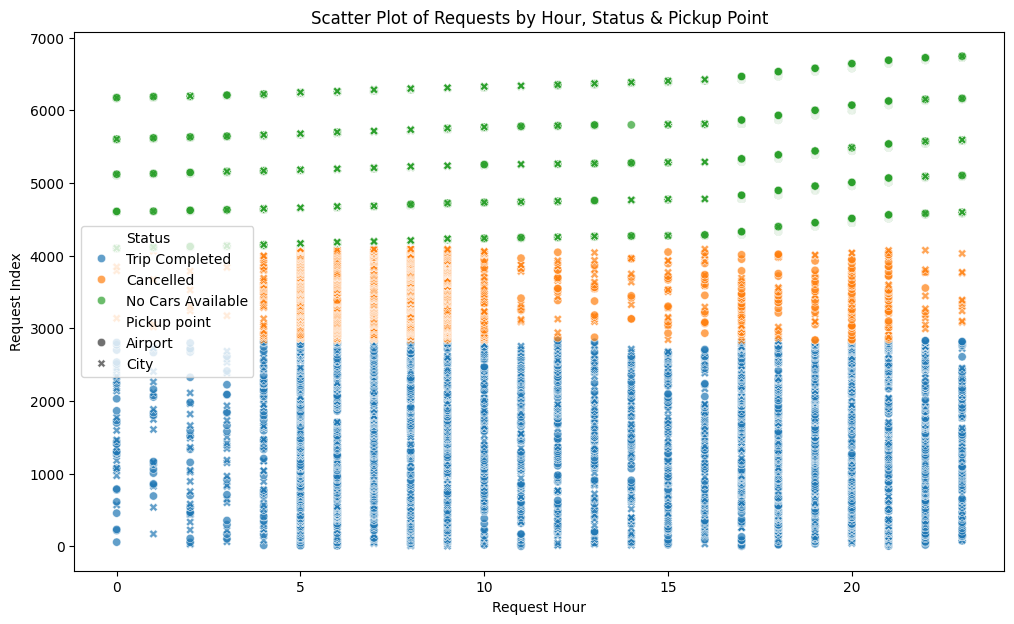

In [145]:
# Chart 20 - Multivariate Analysis
plt.figure(figsize=(12,7))
sns.scatterplot(data=df, x='Request Hour', y=df.index, hue='Status', style='Pickup point', alpha=0.7)
plt.title('Scatter Plot of Requests by Hour, Status & Pickup Point')
plt.xlabel('Request Hour')
plt.ylabel('Request Index')
plt.show()

##### 1. Why did you pick the specific chart?

To see the overall distribution of all requests with multiple dimensions.

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

my suggestions towards achieving the stated business objective (decrease supply-demand gap) are as below:
Short-term Suggestions:

Driver Incentives – Give incentives to drivers who accept City rides during morning (6-10 AM) in order to minimize cancellations.
Deployment during Peak Hours – Increase number of drivers during evening (5-8 PM) hours through surge pricing and shift incentives.
Optimized Matching – Optimize algorithm in order to efficiently match drivers between City and Airport.

Long-term Suggestions:
4. Driver Onboarding – Conduct marketing campaigns to board more drivers, particularly in the City region.
5. Customer Communication – Provide realistic ETA and inform customers to set proper expectations from them.
6. Driver Monitoring – Monitor driver cancellation rate and act against the high frequency of cancellers.
Expected Result:
These measures may help to raise the percentage of completed rides from current 42% to 65-70% in 3-6 months.

# **Conclusion**

Conclusion
This project has helped me get a practical idea about the supply-demand issues that Uber faces. Using extensive Exploratory Data Analysis and 20+ visualizations, I found that the main issues are happening during the Evening period ("High No Cars Available" issue) and Morning period in City area (cancellations).

It has become evident that only 42% of ride requests are successful, which raises a red flag here. Insights generated through Univariate, Bivariate, and Multivariate analysis have made sure that the basis for making informed decisions has been laid.

Final Conclusion:

Using the proposed driver incentives, effective peak hour management, and a better matching system, Uber will be able to fill up the supply demand gap and generate more revenue.


It was a very enriching experience for me as my first major project.

thank you